In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
from lobster import *

In [3]:
ticker = "INTC"
message_path  = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
#[["type", "lvl", "size", "P_1", "Q_1", "P_-1", "Q_-1", "P_2", "Q_2", "P_-2", "Q_-2", "P_3", "Q_3", "P_-3", "Q_-3", "P_4", "Q_4", "P_-4", "Q_-4", "P_5", "Q_5", "P_-5", "Q_-5"]]
df

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,100,275150.0,275200.0,166,...,200,275500.0,0,274800.0,661,275600.0,100,274700.0,300,1
1,34200.006462,0.000221,0.000221,L,275500,4,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
2,34200.048864,0.042402,0.042623,C,275000,-2,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
3,34200.048883,0.000020,0.042642,C,275100,-1,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
4,34200.048989,0.000106,0.000125,L,275000,-2,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580346,57599.860444,0.011408,0.011408,C,267200,1,34600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580347,57599.860635,0.000191,0.223738,L,267000,-2,16600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580348,57599.870108,0.009473,0.249387,C,267400,3,600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580349,57599.939645,0.069536,0.079201,L,267200,1,100,267150.0,267200.0,88204,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157


In [4]:
table1 = make_descriptive_table(df, K=5)
table1

,#L (×10^3),#C (×10^3),#M (×10^2),AES,AIT (ms)
Level,,,,,
1,197.19,162.42,324.82,483.88,119.1
2,40.20,59.75,0.00,441.55,462.3
3,22.71,22.55,0.00,451.23,1004.4
4,13.23,11.88,0.00,475.07,1672.0
5,9.50,8.44,0.00,596.93,2263.0


In [5]:
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df_norm = normalize_by_aes(df, aes=aes, K=5)
df_norm.head(10)

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,...,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1,1
1,34200.006462,0.000221,0.000221,L,275500,4,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
2,34200.048864,0.042402,0.042623,C,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
3,34200.048883,0.000020,0.042642,C,275100,-1,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
4,34200.048989,0.000106,0.000125,L,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
5,34200.049011,0.000022,0.042770,L,274900,-3,2,275150.0,275200.0,1,...,2,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
6,34200.049078,0.000068,0.042837,L,274800,-4,2,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,1,1
7,34200.049110,0.000032,0.042869,L,274700,-5,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1
8,34200.049301,0.000190,0.000311,L,275000,-2,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1
9,34200.211338,0.162038,0.205097,M,275200,1,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1


### Training DataFrame: ###
From where we will extract our different state vectors $x_k$.

In [6]:
df_train = df_norm.copy()

def build_training_dfs_by_level(df_train):
    event_map = {"L": 0, "C": 1, "M": 2}
    out = {}

    for lvl, df in df_train.groupby("lvl"):
        df = df.copy()

        # 1) Event ID
        df["event_id"] = df["type"].map(event_map)

        # 2) Hour of last event
        df["hour_last_event"] = df["time"].shift(1) // 3600

        # 3) Last event ID
        df["last_event_id"] = df["event_id"].shift(1)

        # 4) Queue before event
        df["q"] = df[f"Q_{lvl}"].shift(1)

        # Formatting
        df = df.dropna().reset_index(drop=True)
        df["hour_last_event"] = df["hour_last_event"].astype("int64")
        hour_map = {h: i for i, h in enumerate(sorted(df["hour_last_event"].unique()))}
        df["hour_last_event"] = df["hour_last_event"].map(hour_map)
        df["last_event_id"] = df["last_event_id"].astype("int64")
        df["q"] = df["q"].astype("int64")

        out[lvl] = df[["event_id", "dtk_l", "q", "hour_last_event", "last_event_id"]]

    return out

def build_training_dfs_by_abs_level(df_train):
    dfs_by_level = build_training_dfs_by_level(df_train)
    dfs_by_abs_level = {}

    abs_levels = sorted({abs(lvl) for lvl in dfs_by_level.keys()})

    for k in abs_levels:
        parts = []
        if -k in dfs_by_level:
            parts.append(dfs_by_level[-k].copy())
        if k in dfs_by_level:
            parts.append(dfs_by_level[k].copy())

        if parts:
            dfs_by_abs_level[k] = pd.concat(parts, ignore_index=True)

    return dfs_by_abs_level

In [7]:
dfs_by_abs_level = build_training_dfs_by_abs_level(df_train)
print(dfs_by_abs_level.keys())

dict_keys([1, 2, 3, 4, 5])


In [8]:
dfs_by_abs_level[1]

,event_id,dtk_l,q,hour_last_event,last_event_id
0,0,0.162572,1,0,1
1,0,0.000007,2,0,0
2,0,0.000002,2,0,0
3,1,0.000094,2,0,0
4,0,0.000000,2,0,1
...,...,...,...,...,...
392088,1,0.010125,256,6,1
392089,1,0.206373,253,6,1
392090,0,0.014818,252,6,1
392091,1,0.011408,254,6,0


### QR Model Intensities ###

In [9]:
from qrFunctions import shift_orderbook_before_event, build_all_sequences, estimate_all_qr
df_qr = shift_orderbook_before_event(df_norm, K=5)
df_qr = df_qr.dropna().reset_index(drop=True)
seqs = build_all_sequences(df_qr, K=5)
lambdas, Ns, Ts = estimate_all_qr(seqs)

In [10]:
from qrFunctions import qr_transition_matrix
qr_matrix = qr_transition_matrix(Ns, K=K)
qr_matrix

,cancel,limit,trade
cancel,0.456695,0.487335,0.05597
limit,0.456695,0.487335,0.05597
trade,0.456695,0.487335,0.05597


### Training / Target vectors: ###

Vanilla : $x_k = [q_k]$

Hours: $x_k = [q_k, h_k]$

Last Event: $x_k = [q_k, \eta_{k-1}]$

Hours + Last Event: $x_k = [q_k, h_k, \eta_{k-1}]$

In [11]:
from dqrfunctions import build_dataset

df_train_1 = build_dataset(dfs_by_abs_level[1], use_hour=True, use_last_event=True)
df_train_2 = build_dataset(dfs_by_abs_level[2], use_hour=True, use_last_event=True)
df_train_3 = build_dataset(dfs_by_abs_level[3], use_hour=True, use_last_event=True)
df_train_4 = build_dataset(dfs_by_abs_level[4], use_hour=True, use_last_event=True)
df_train_5 = build_dataset(dfs_by_abs_level[5], use_hour=True, use_last_event=True)

display(df_train_1)

{'q': tensor([  1.,   2.,   2.,  ..., 252., 254., 183.]),
 'y': tensor([0, 0, 0,  ..., 0, 1, 0]),
 'dt': tensor([1.6257e-01, 6.8950e-06, 1.5020e-06,  ..., 1.4818e-02, 1.1408e-02,
         7.9201e-02]),
 'last_event': tensor([1, 0, 0,  ..., 1, 0, 1]),
 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}

### Neural Network Definition ###

In [12]:
from dqrfunctions import DQRNet

### Negative Log Likelihood ###

$\text{loss}\left(\theta | \epsilon\right) = l\left(\lambda_\theta | \epsilon\right) = \sum_{i=1}^{B} \left( \Lambda_\theta(x_k)\Delta t_k - \log{\lambda_\theta^{\eta_k}(x_k)} \right)$

In [13]:
from dqrfunctions import dqr_loss

### Training Loop ###

In [14]:
from dqrfunctions import train_model, get_or_train_model

### Model Training ###

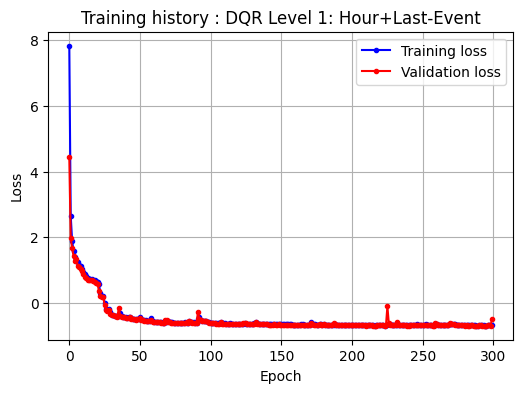

In [15]:
model_level_1 = get_or_train_model(
    f"models/{ticker}/dqr_level_1.pt",
    data=df_train_1,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[1]["hour_last_event"].nunique())
model_level_1.plot_history(model_name="Level 1: Hour+Last-Event")

In [16]:
model_level_2 = get_or_train_model(
    f"models/{ticker}/dqr_level_2.pt",
    data=df_train_2,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[2]["hour_last_event"].nunique())

In [17]:
model_level_3 = get_or_train_model(
    f"models/{ticker}/dqr_level_3.pt",
    data=df_train_3,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[3]["hour_last_event"].nunique())

In [18]:
model_level_4 = get_or_train_model(
    f"models/{ticker}/dqr_level_4.pt",
    data=df_train_4,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[4]["hour_last_event"].nunique())

In [19]:
model_level_5 = get_or_train_model(
    f"models/{ticker}/dqr_level_5.pt",
    data=df_train_5,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[5]["hour_last_event"].nunique())

### Simulation of LOB ###

### Transition Matrixes ###

In [36]:
df_level_1 = dfs_by_abs_level[1].copy()
display(df_level_1)
display(df_train_1)

,event_id,dtk_l,q,hour_last_event,last_event_id
0,0,0.162572,1,0,1
1,0,0.000007,2,0,0
2,0,0.000002,2,0,0
3,1,0.000094,2,0,0
4,0,0.000000,2,0,1
...,...,...,...,...,...
392088,1,0.010125,256,6,1
392089,1,0.206373,253,6,1
392090,0,0.014818,252,6,1
392091,1,0.011408,254,6,0


{'q': tensor([  1.,   2.,   2.,  ..., 252., 254., 183.]),
 'y': tensor([0, 0, 0,  ..., 0, 1, 0]),
 'dt': tensor([1.6257e-01, 6.8950e-06, 1.5020e-06,  ..., 1.4818e-02, 1.1408e-02,
         7.9201e-02]),
 'last_event': tensor([1, 0, 0,  ..., 1, 0, 1]),
 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}

In [45]:
from dqrfunctions import transition_real, transition_dqr

df_level_1 = dfs_by_abs_level[1].copy()

event_id_np = df_level_1["event_id"].to_numpy()
last_id_np  = df_level_1["last_event_id"].to_numpy()
# DQR: last_event_id must match X lines format (torch)
last_id_t = torch.tensor(last_id_np, dtype=torch.long)

T_real = transition_real(event_id_np, last_id_np, n_events=3)
T_dqr = transition_dqr(
                        model=model_level_1,
                        data=df_train_1,
                        last_event_id=last_id_t,
                        n_events=3)
T_qr = qr_matrix.to_numpy()

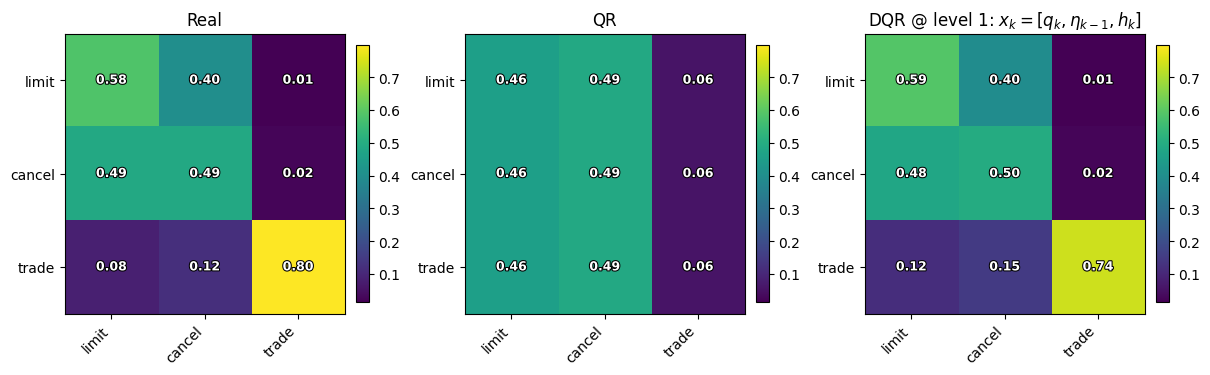

In [46]:
from dqrfunctions import plot_two_heatmaps, plot_three_heatmaps

EVENT_NAMES = ["limit", "cancel", "trade"]
dqr_title = r"DQR @ level 1: $x_k=[q_k,\eta_{k-1},h_k]$"

fig = plot_three_heatmaps(T_real, T_qr, T_dqr, labels=EVENT_NAMES, dqr_title=dqr_title)
plt.show()

In [39]:
from dqrfunctions import compute_hourly_intensity, compute_real_hourly_intensity
hourly_dqr = compute_hourly_intensity(model_level_1, df_train_1, df_level_1["hour_last_event"].values)
hourly_real = compute_real_hourly_intensity(df_level_1, trade_id=2)

#from qrFunctions import compute_hourly_intensity_qr
#hourly_qr, constant_hourly_qr = compute_hourly_intensity_qr(lambdas, df_train)

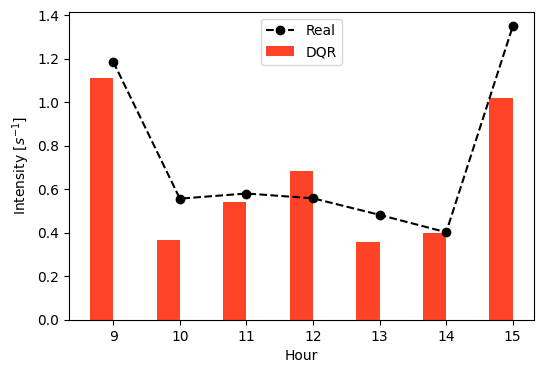

In [40]:
width = 0.35
x = hourly_dqr.index.values + 9
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x - width/2, hourly_dqr.values, width=width, color="#FF4327", label="DQR")
ax.plot(x, hourly_real.values, "o--", color="black", label="Real")
#ax.plot(hourly_qr.index, hourly_qr.values, label="QR", marker='^', linestyle='--', color='darkblue')
#ax.axhline(constant_hourly_qr, xmin=x.min(), xmax=x.max(), color='black', linestyle='-', label='QR (Constant)')
ax.set_xlabel("Hour")
ax.set_ylabel(r"Intensity [$s^{-1}$]")
ax.set_xticks(x)
ax.legend()
plt.show()